In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (10, 6)

PALETA_PRINCIPAL = sns.color_palette("crest", 10)
COLOR_ACENTO = "#458284"

In [2]:
df = pd.read_csv('../data/Processed/online_retail_CLEAN.csv', parse_dates=['InvoiceDate'])

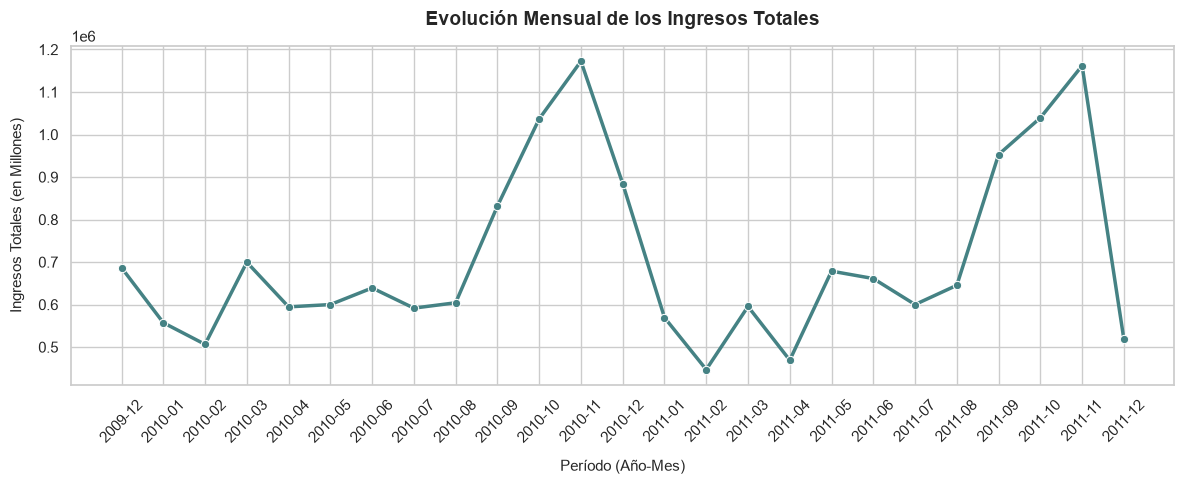

In [3]:
df['Periodo'] = df['InvoiceDate'].dt.to_period('M')


ventas_mensuales = df.groupby('Periodo')['TotalVenta'].sum().reset_index()
ventas_mensuales['Periodo_Str'] = ventas_mensuales['Periodo'].astype(str)


plt.figure(figsize=(12, 5))
sns.lineplot(data=ventas_mensuales, x='Periodo_Str', y='TotalVenta', marker='o', color=COLOR_ACENTO, linewidth=2.5)

plt.title('Evolución Mensual de los Ingresos Totales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Período (Año-Mes)', fontsize=11, labelpad=10)
plt.ylabel('Ingresos Totales (en Millones)', fontsize=11, labelpad=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

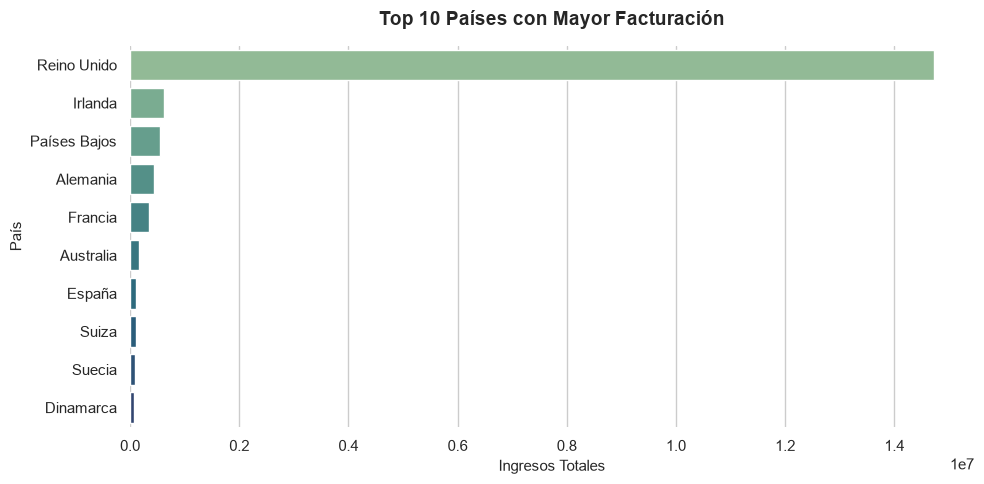

In [4]:
ventas_por_pais = df.groupby('Country')['TotalVenta'].sum().reset_index()
top_paises = ventas_por_pais.sort_values(by='TotalVenta', ascending=False).head(10)


plt.figure(figsize=(10, 5))
sns.barplot(data=top_paises, x='TotalVenta', y='Country', palette="crest")

plt.title('Top 10 Países con Mayor Facturación', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ingresos Totales', fontsize=11)
plt.ylabel('País', fontsize=11)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

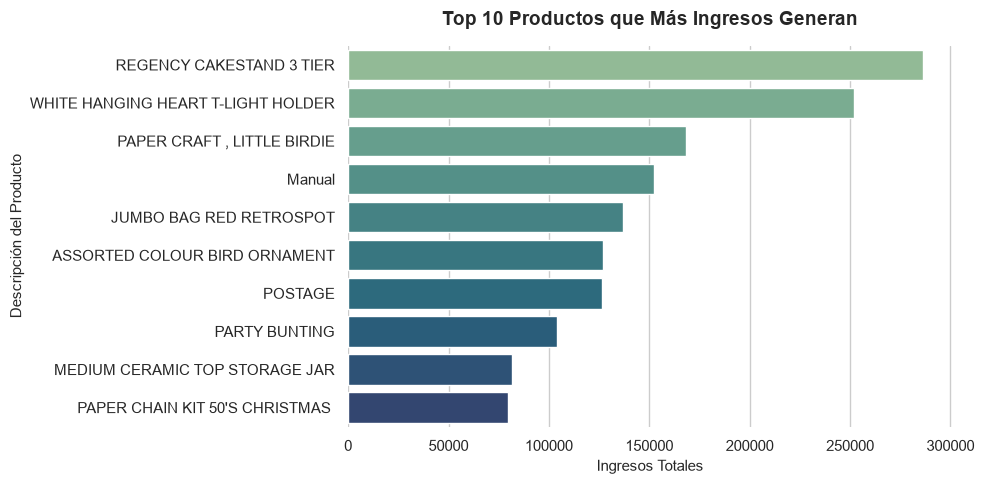

In [5]:
productos = df.groupby(['StockCode', 'Description']).agg(
    Cantidad_Vendida=('Quantity', 'sum'),
    Ingresos_Totales=('TotalVenta', 'sum')
).reset_index()


top_productos_ingresos = productos.sort_values(by='Ingresos_Totales', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_productos_ingresos, x='Ingresos_Totales', y='Description', palette="crest")

plt.title('Top 10 Productos que Más Ingresos Generan', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ingresos Totales', fontsize=11)
plt.ylabel('Descripción del Producto', fontsize=11)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

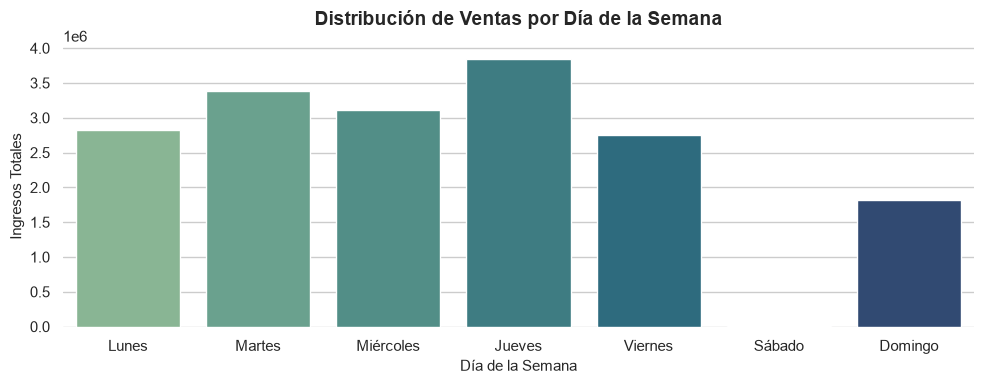

In [6]:
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
ventas_dias = df.groupby('DiaSemana')['TotalVenta'].sum().reindex(orden_dias).reset_index()

plt.figure(figsize=(10, 4))
sns.barplot(data=ventas_dias, x='DiaSemana', y='TotalVenta', palette="crest")

plt.title('Distribución de Ventas por Día de la Semana', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Día de la Semana', fontsize=11)
plt.ylabel('Ingresos Totales', fontsize=11)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()